# AgenticML — Comparação Final com Baseline AutoML (TCC)

**Objetivo:** Comparar o AgenticML com o FLAML (baseline AutoML) em 3 datasets, sob um
protocolo com holdout isolado e repetições multi-seed — a métrica reportada nunca é a
mesma usada para selecionar o modelo.

| Dataset | Tipo | Métrica |
|---------|------|---------|
| Iris | Classificação multiclasse | F1-weighted |
| Titanic | Classificação binária | F1-weighted |
| California Housing | Regressão | R² |

**Referência spec:** Seção 9.1 — Métricas Quantitativas

> **Nota metodológica:** uma análise exploratória inicial (1 execução por dataset, sem
> holdout isolado) sugeriu vantagem do AgenticML sobre o FLAML. Ela NÃO se sustentou sob
> o protocolo rigoroso abaixo e foi removida deste notebook — ver discussão no texto do
> TCC. Os números desta versão são os únicos válidos para citação.

In [10]:
import sys, os, time, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.datasets import load_iris, fetch_california_housing
from core.graph import build_graph
from core.state import initial_state

print('Ambiente configurado.')
from tcc_eval import (
    DATASETS, load_dataset, make_split, export_split,
    run_multiseed, merge_flaml_csv, summarize, paired_comparison,
)


Ambiente configurado.


---
## Protocolo robusto: holdout isolado + repetições multi-seed

Esta seção:
1. Gera um split **train/test holdout isolado e semeado** por dataset — o AgenticML nunca
   vê o test durante a seleção de modelo.
2. Repete o experimento em **múltiplas sementes**, reportando média ± IC 95% em vez de um
   único ponto.
3. Exporta os splits em CSV para que o **FLAML rode exatamente na mesma partição** (Colab).
4. Aplica um teste pareado (Wilcoxon + t) para dizer se a diferença entre AgenticML e
   FLAML é estatisticamente robusta ou pode ser variabilidade amostral.

> Os números desta seção são os que devem ser citados no corpo do TCC.

In [11]:
SEEDS = list(range(10))  # 10 sementes: mínimo para o Wilcoxon poder atingir p<0.05 (2/2**n)
SPLITS_DIR = 'flaml_splits'
FLAML_TIME_BUDGET = 240  # mesmo budget intermediário usado nas Partes 1-4

print(f'{len(SEEDS)} sementes: {SEEDS}')

10 sementes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [12]:
long_rows = []
for name in DATASETS:
    df, target, task, prompt, hint = load_dataset(name)

    res = run_multiseed(
        df, name, target, prompt, hint, task, SEEDS,
        run_flaml=False,  # FLAML roda à parte no Colab, na MESMA partição (ver instruções abaixo)
        on_progress=print,
    )
    long_rows.append(res)

    # Exporta os splits — a mesma partição que o FLAML deve consumir no Colab
    for seed in SEEDS:
        tr, te, _ = make_split(df, target, task, seed=seed)
        export_split(tr, te, SPLITS_DIR, f"{name.lower().replace(' ', '_')}_seed{seed}")

long_df = pd.concat(long_rows, ignore_index=True)
long_df.to_csv('agenticml_multiseed_results.csv', index=False)
display(long_df)

[Iris seed=0] AgenticML Logistic Regression f1_weighted=1.0
[Iris seed=1] AgenticML XGBoost f1_weighted=0.9332
[Iris seed=2] AgenticML SVM f1_weighted=1.0
[Iris seed=3] AgenticML Logistic Regression f1_weighted=0.8667
[Iris seed=4] AgenticML SVM f1_weighted=0.9327
[Iris seed=5] AgenticML SVM f1_weighted=0.9666
[Iris seed=6] AgenticML SVM f1_weighted=0.9666
[Iris seed=7] AgenticML Logistic Regression f1_weighted=1.0
[Iris seed=8] AgenticML Logistic Regression f1_weighted=0.9666
[Iris seed=9] AgenticML SVM f1_weighted=0.9666
[Titanic seed=0] AgenticML SVM f1_weighted=0.8128
[Titanic seed=1] AgenticML XGBoost f1_weighted=0.8302
[Titanic seed=2] AgenticML XGBoost f1_weighted=0.8516
[Titanic seed=3] AgenticML Random Forest f1_weighted=0.8659
[Titanic seed=4] AgenticML Random Forest f1_weighted=0.8402
[Titanic seed=5] AgenticML XGBoost f1_weighted=0.8068
[Titanic seed=6] AgenticML XGBoost f1_weighted=0.793
[Titanic seed=7] AgenticML Random Forest f1_weighted=0.8007
[Titanic seed=8] AgenticML

,dataset,system,seed,metric_name,metric,rmse,model,elapsed,cv_score,optimism_gap,balancing
0,Iris,AgenticML,0,f1_weighted,1.0000,None,Logistic Regression,17.08,0.9747,-0.0253,nenhum
1,Iris,AgenticML,1,f1_weighted,0.9332,None,XGBoost,16.34,0.9582,0.0250,nenhum
2,Iris,AgenticML,2,f1_weighted,1.0000,None,SVM,14.93,0.9833,-0.0167,nenhum
3,Iris,AgenticML,3,f1_weighted,0.8667,None,Logistic Regression,14.59,0.9749,0.1082,nenhum
4,Iris,AgenticML,4,f1_weighted,0.9327,None,SVM,20.61,0.9747,0.0420,nenhum
5,Iris,AgenticML,5,f1_weighted,0.9666,None,SVM,13.35,0.9833,0.0167,nenhum
6,Iris,AgenticML,6,f1_weighted,0.9666,None,SVM,13.39,0.9750,0.0084,nenhum
7,Iris,AgenticML,7,f1_weighted,1.0000,None,Logistic Regression,13.86,0.9749,-0.0251,nenhum
8,Iris,AgenticML,8,f1_weighted,0.9666,None,Logistic Regression,14.06,0.9833,0.0167,nenhum
9,Iris,AgenticML,9,f1_weighted,0.9666,None,SVM,20.34,0.9666,0.0000,nenhum


### FLAML no Colab (mesma partição, todas as sementes)

1. Suba a pasta `flaml_splits/` gerada acima (`<dataset>_seed<N>_train.csv` / `_test.csv`).
2. Para cada dataset × semente, rode o FLAML com `time_budget=240` (mesmo budget do meio
   usado na Parte 2) treinando no `train` e avaliando no `test` correspondente.
3. Salve os resultados em `flaml_multiseed_results.csv` com as colunas:
   `dataset, seed, metric_name, metric[, rmse, model, elapsed]` — o valor de `dataset`
   deve ser exatamente `Iris`, `Titanic` ou `California Housing` (mesmos nomes do
   registro `DATASETS` em `tcc_eval.py`).
4. Baixe o CSV para esta pasta (`notebooks/experiments/flaml_multiseed_results.csv`) e
   rode a célula abaixo.

In [13]:
import os as _os

FLAML_CSV = 'flaml_multiseed_results.csv'

if _os.path.exists(FLAML_CSV):
    long_df = merge_flaml_csv(long_df, FLAML_CSV)
    have_flaml = True
else:
    have_flaml = False
    print(
        f"⚠ '{FLAML_CSV}' não encontrado — rode o FLAML no Colab (instruções acima) e "
        "coloque o CSV nesta pasta antes de prosseguir.\n"
        "As células abaixo mostram, por enquanto, só o AgenticML."
    )

summary = summarize(long_df)
display(summary)

,dataset,system,metric_name,n,mean,std,ci95_low,ci95_high,min,max,rmse_mean,rmse_std
0,Iris,AgenticML,f1_weighted,10,0.9599,0.0410,0.9306,0.9892,0.8667,1.0000,NaN,NaN
1,Titanic,AgenticML,f1_weighted,10,0.8305,0.0268,0.8113,0.8497,0.7930,0.8690,NaN,NaN
2,California Housing,AgenticML,r2,10,0.7554,0.0250,0.7376,0.7733,0.7182,0.7998,0.5744,0.0321
3,Iris,FLAML,f1_weighted,10,0.9599,0.0212,0.9447,0.9750,0.9327,1.0000,NaN,NaN
4,Titanic,FLAML,f1_weighted,10,0.8304,0.0185,0.8172,0.8437,0.8083,0.8601,NaN,NaN
5,California Housing,FLAML,r2,10,0.7602,0.0322,0.7372,0.7832,0.6946,0.8102,0.5684,0.0412


In [14]:
if have_flaml:
    for name in DATASETS:
        r = paired_comparison(long_df, name)
        print(f"[{name}] {r.get('verdict', r.get('error'))}")
else:
    print('Teste pareado pendente — requer os resultados do FLAML (ver célula acima).')

[Iris] Diferença média de +0.0000 NÃO é estatisticamente significativa (Wilcoxon p=0.711, t pareado p=0.999, n=10). A vantagem observada pode decorrer de variabilidade amostral.
[Titanic] Diferença média de +0.0001 NÃO é estatisticamente significativa (Wilcoxon p=0.922, t pareado p=0.989, n=10). A vantagem observada pode decorrer de variabilidade amostral.
[California Housing] Diferença média de -0.0048 NÃO é estatisticamente significativa (Wilcoxon p=0.432, t pareado p=0.332, n=10). A vantagem observada pode decorrer de variabilidade amostral.


---
## Parte 6 — Gráficos do protocolo robusto (multi-seed)

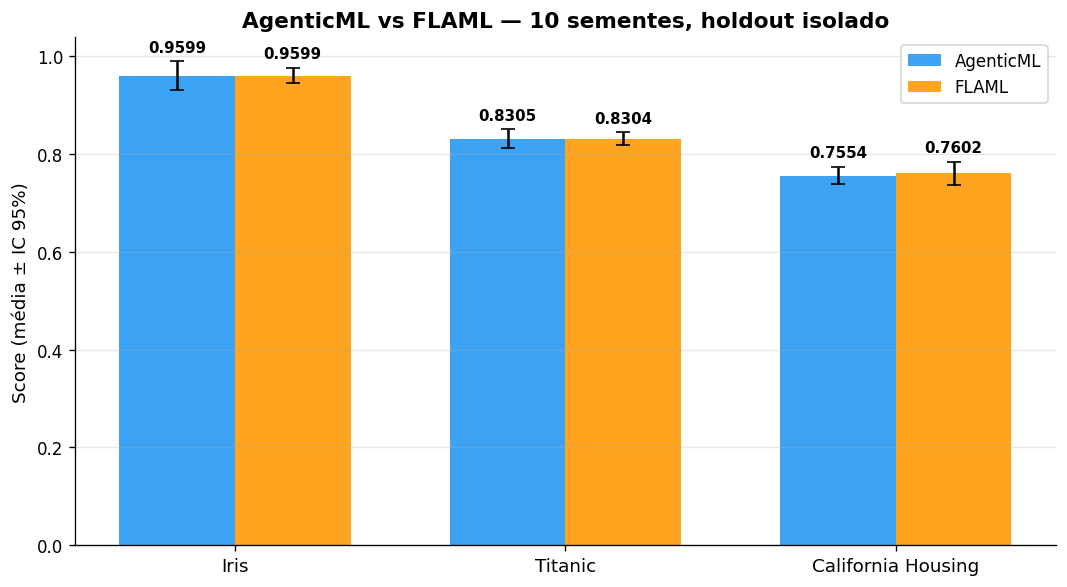

Gráfico salvo em comparacao_multiseed.png


In [15]:
ds_order = list(DATASETS.keys())
x = np.arange(len(ds_order))
w = 0.35 if have_flaml else 0.5


def _vals(system):
    means, los, his = [], [], []
    for ds in ds_order:
        row = summary[(summary['dataset'] == ds) & (summary['system'] == system)]
        if row.empty:
            means.append(np.nan); los.append(0.0); his.append(0.0)
        else:
            r = row.iloc[0]
            means.append(r['mean'])
            los.append(r['mean'] - r['ci95_low'])
            his.append(r['ci95_high'] - r['mean'])
    return means, [los, his]


fig, ax = plt.subplots(figsize=(9, 5))

m_ag, err_ag = _vals('AgenticML')
bars1 = ax.bar(x - (w / 2 if have_flaml else 0), m_ag, w, yerr=err_ag, capsize=4,
               label='AgenticML', color='#2196F3', alpha=0.88)
ax.bar_label(bars1, fmt='%.4f', padding=4, fontsize=9, fontweight='bold')

if have_flaml:
    m_fl, err_fl = _vals('FLAML')
    bars2 = ax.bar(x + w / 2, m_fl, w, yerr=err_fl, capsize=4,
                   label='FLAML', color='#FF9800', alpha=0.88)
    ax.bar_label(bars2, fmt='%.4f', padding=4, fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(ds_order, fontsize=11)
ax.set_ylabel('Score (média ± IC 95%)', fontsize=11)
ax.set_title(f'AgenticML vs FLAML — {len(SEEDS)} sementes, holdout isolado',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('comparacao_multiseed.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em comparacao_multiseed.png')

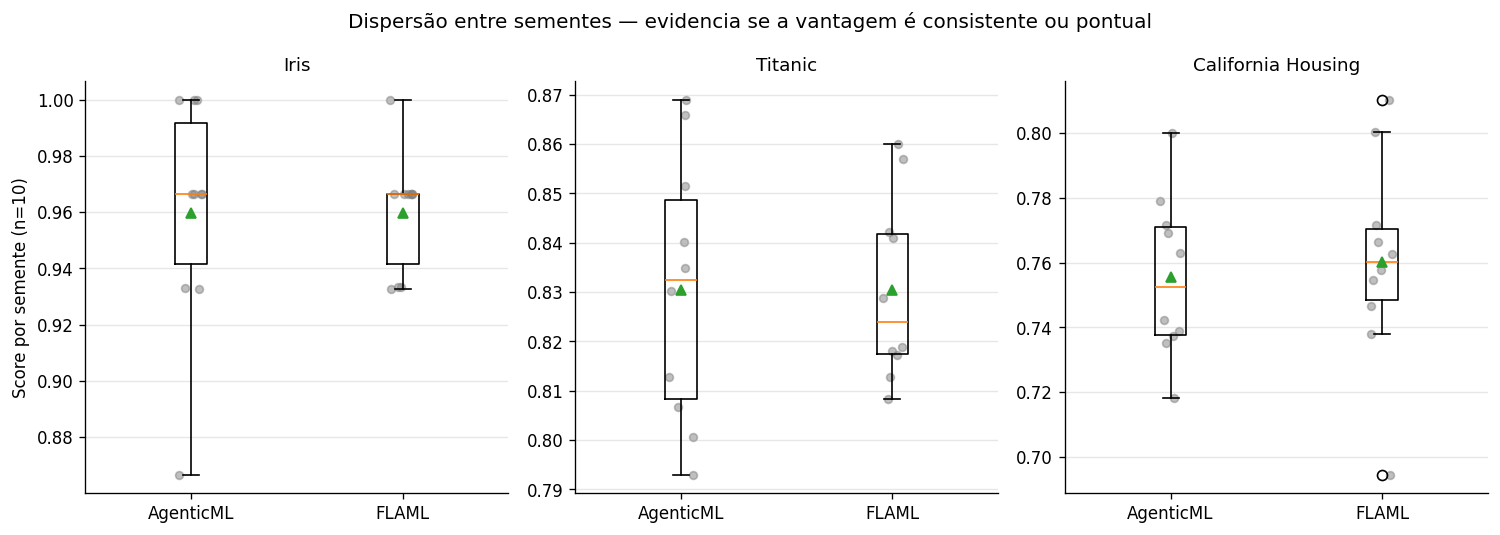

Gráfico salvo em dispersao_multiseed.png


In [16]:
fig, axes = plt.subplots(1, len(ds_order), figsize=(4.2 * len(ds_order), 4.5))
if len(ds_order) == 1:
    axes = [axes]

rng = np.random.default_rng(0)
for ax, ds in zip(axes, ds_order):
    sub = long_df[long_df['dataset'] == ds]
    systems = [s for s in ('AgenticML', 'FLAML') if s in sub['system'].unique()]
    data = [sub[sub['system'] == s]['metric'].dropna().values for s in systems]
    ax.boxplot(data, tick_labels=systems, showmeans=True)
    for i, s in enumerate(systems, start=1):
        vals = sub[sub['system'] == s]['metric'].dropna().values
        jitter = rng.uniform(-0.06, 0.06, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.5, s=22, color='gray')
    ax.set_title(ds, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel(f'Score por semente (n={len(SEEDS)})')
plt.suptitle('Dispersão entre sementes — evidencia se a vantagem é consistente ou pontual',
             fontsize=12)
plt.tight_layout()
plt.savefig('dispersao_multiseed.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em dispersao_multiseed.png')